# 02_eda_advanced – Exploratory Data Analysis

**Goal:** Understand the Ames Housing dataset deeply – uncover patterns, detect anomalies, and generate hypotheses for feature engineering. This EDA will guide the creation of new features in the next notebook.

**Key questions:**
- What does the target (`SalePrice`) distribution look like?
- Which features correlate strongly with price?
- Are there missing values that need special handling?
- Can we create new features (interactions, ratios, aggregates) that might improve model performance?
- Are there any remaining outliers beyond the two already removed?

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# For reproducibility
RANDOM_STATE = 42

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

We use the same outlier‑removed data as in the baseline notebook.
Note: The two extreme outliers (GrLivArea > 4000 and SalePrice < 300,000) have already been removed.

In [2]:
data_path = Path("../data/raw/train.csv")
df = pd.read_csv(data_path)
print(f"Original shape: {df.shape}")

# Remove the known outliers (same as baseline)
outlier_idx = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)].index
df = df.drop(outlier_idx)
print(f"Shape after outlier removal: {df.shape}")

# Separate features and target for later use
y = df['SalePrice']
X = df.drop(['Id', 'SalePrice'], axis=1)

Original shape: (1460, 81)
Shape after outlier removal: (1458, 81)


## 3. Target Variable Analysis

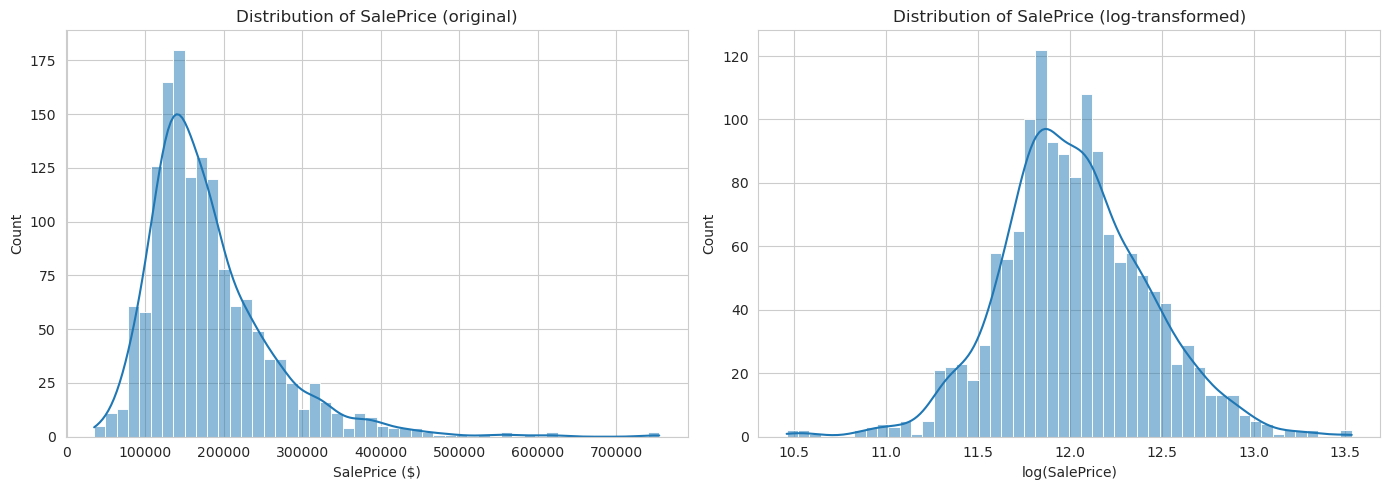

Skewness (original): 1.881
Skewness (log): 0.122


In [3]:
# Distribution of SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
sns.histplot(y, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of SalePrice (original)')
axes[0].set_xlabel('SalePrice ($)')

# Log-transformed
y_log = np.log1p(y)
sns.histplot(y_log, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of SalePrice (log-transformed)')
axes[1].set_xlabel('log(SalePrice)')

plt.tight_layout()
plt.show()

print(f"Skewness (original): {y.skew():.3f}")
print(f"Skewness (log): {y_log.skew():.3f}")

**Observations:**

- Original SalePrice is right‑skewed (skewness > 1).
- Log transformation makes it nearly normal – justifies using log target in modeling.

## 4. Missing Data Analysis

In [5]:
# Calculate missing percentage per column
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(X)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Columns with missing values:")
missing_df

Columns with missing values:


,Missing Count,Percentage
PoolQC,1452,99.588477
MiscFeature,1404,96.296296
Alley,1367,93.758573
Fence,1177,80.727023
MasVnrType,872,59.807956
FireplaceQu,690,47.325103
LotFrontage,259,17.764060
GarageType,81,5.555556
GarageYrBlt,81,5.555556
GarageFinish,81,5.555556


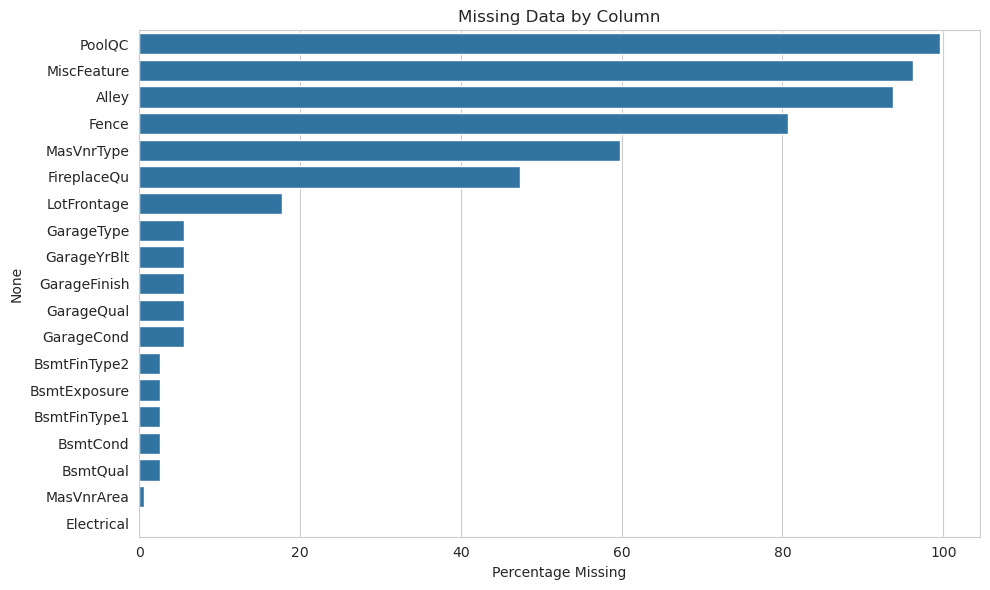

In [6]:
# Visualize missing data
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel('Percentage Missing')
plt.title('Missing Data by Column')
plt.tight_layout()
plt.show()

**Common missing patterns:**

- PoolQC, MiscFeature, Alley, Fence, FireplaceQu, missing means “none” (no pool, alley, etc.)
- LotFrontage – missing for some houses; likely related to lot shape or neighborhood.
- Garage and Basement features – missing when there is no garage/basement.

*Action: We’ll handle these appropriately during feature engineering (fill categorical with "None", impute LotFrontage by neighborhood median).*

## 5. Numerical Features

First, we list all numerical features (excluding Id).

In [7]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numerical features: {len(num_cols)}")

Number of numerical features: 36


### 5.1 Distribution of key numerical features

We pick the top 10 features with highest absolute correlation to SalePrice (we'll compute correlations next).

In [9]:
# Correlation with SalePrice (on original scale)
corr_with_price = X[num_cols].corrwith(y).abs().sort_values(ascending=False)
top10_num = corr_with_price.head(10).index.tolist()
print("Top 10 numerical features by absolute correlation with SalePrice:")
print(top10_num)

Top 10 numerical features by absolute correlation with SalePrice:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', '1stFlrSF', 'GarageArea', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


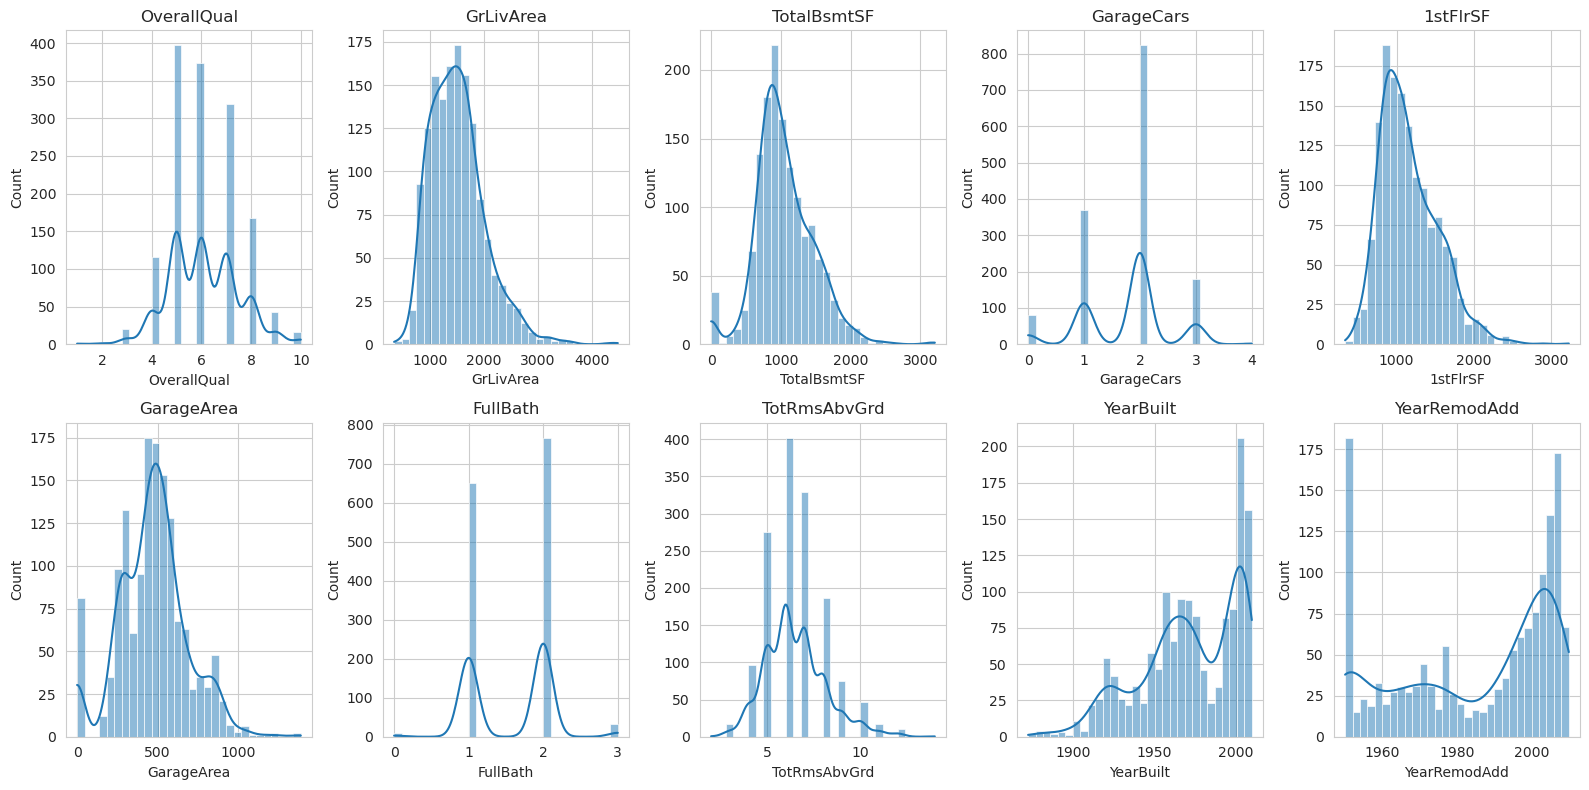

In [10]:
# Plot distributions for these top features
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top10_num):
    sns.histplot(X[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

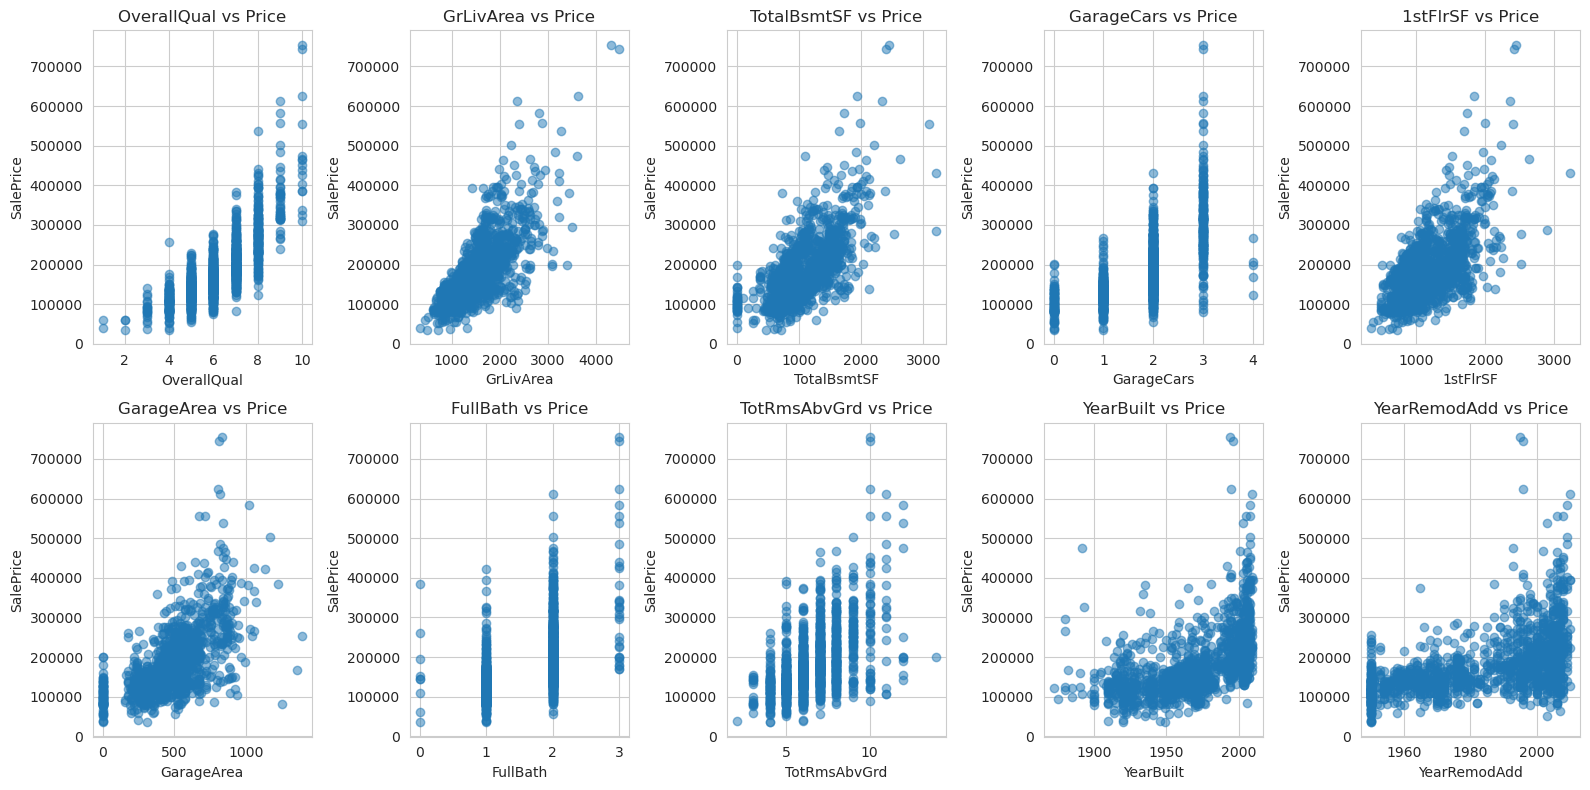

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(top10_num):
    axes[i].scatter(X[col], y, alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs Price')
plt.tight_layout()
plt.show()

**Observations:**

-    OverallQual shows a strong positive relationship, likely the most important feature.

-    GrLivArea also strong, but with a few high‑area low‑price points (already removed outliers, but check if any remain).

-    TotalBsmtSF, GarageArea, positive but with some zeros (no basement/garage).

-    Some features like YearBuilt show non‑linear patterns.

## 6. Categorical Features

In [13]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(cat_cols)}")

Number of categorical features: 43


## 6.1 Frequency and price relationship

For a few important categories, plot mean price per category.

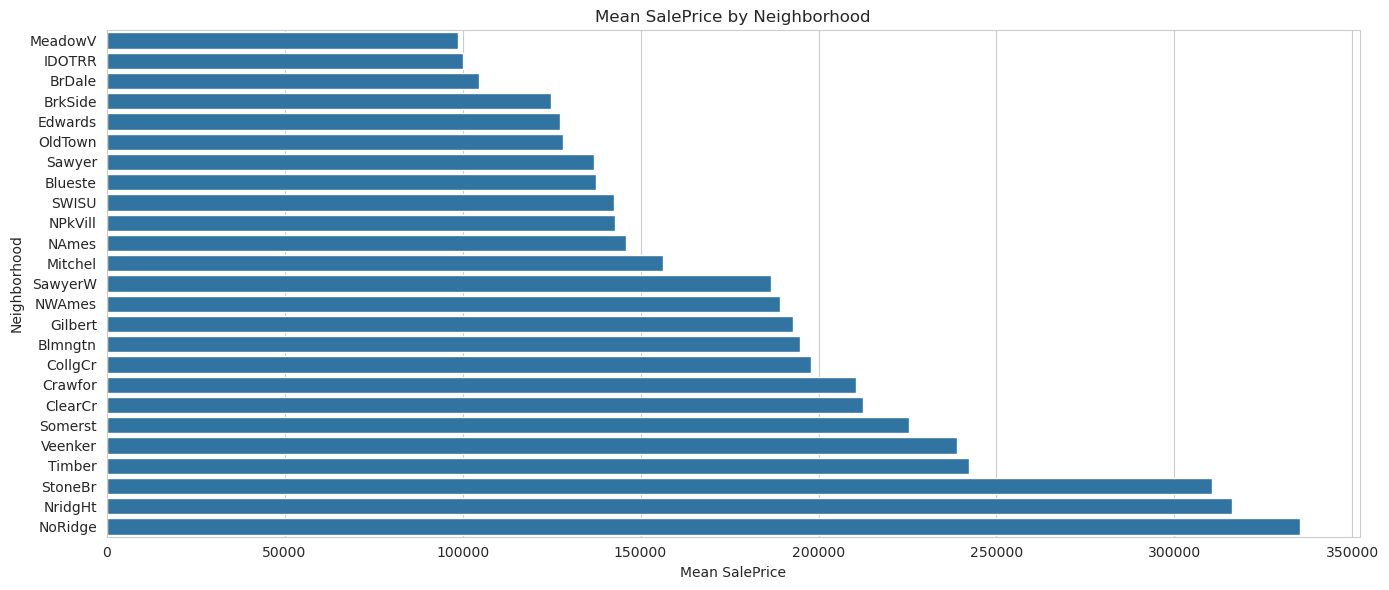

In [14]:
# Pick a few interesting categorical columns
important_cats = ['Neighborhood', 'MSZoning', 'SaleCondition', 'OverallQual']  # OverallQual is actually ordinal but stored as int – treat as categorical for now
# Actually OverallQual is numeric, so we'll use it later.

# Neighborhood is key – let's examine it
plt.figure(figsize=(14, 6))
neigh_mean = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()
sns.barplot(x=neigh_mean.values, y=neigh_mean.index)
plt.xlabel('Mean SalePrice')
plt.title('Mean SalePrice by Neighborhood')
plt.tight_layout()
plt.show()

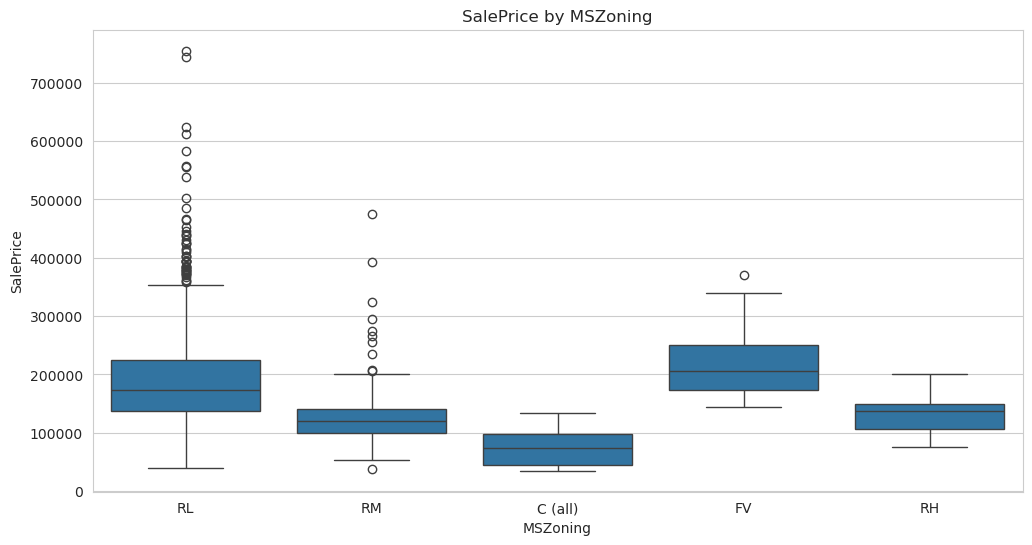

In [15]:
# Boxplot of SalePrice by MSZoning
plt.figure(figsize=(12, 6))
sns.boxplot(x='MSZoning', y='SalePrice', data=df)
plt.title('SalePrice by MSZoning')
plt.show()

**Observations:**

- Neighborhood strongly influences price – we may want to create neighborhood‑level aggregates (e.g., median price, quality score).

- Zoning, sale condition, etc., show differences.

## 7. Feature Relationships and Interactions
### 7.1 Correlation heatmap (numerical features)

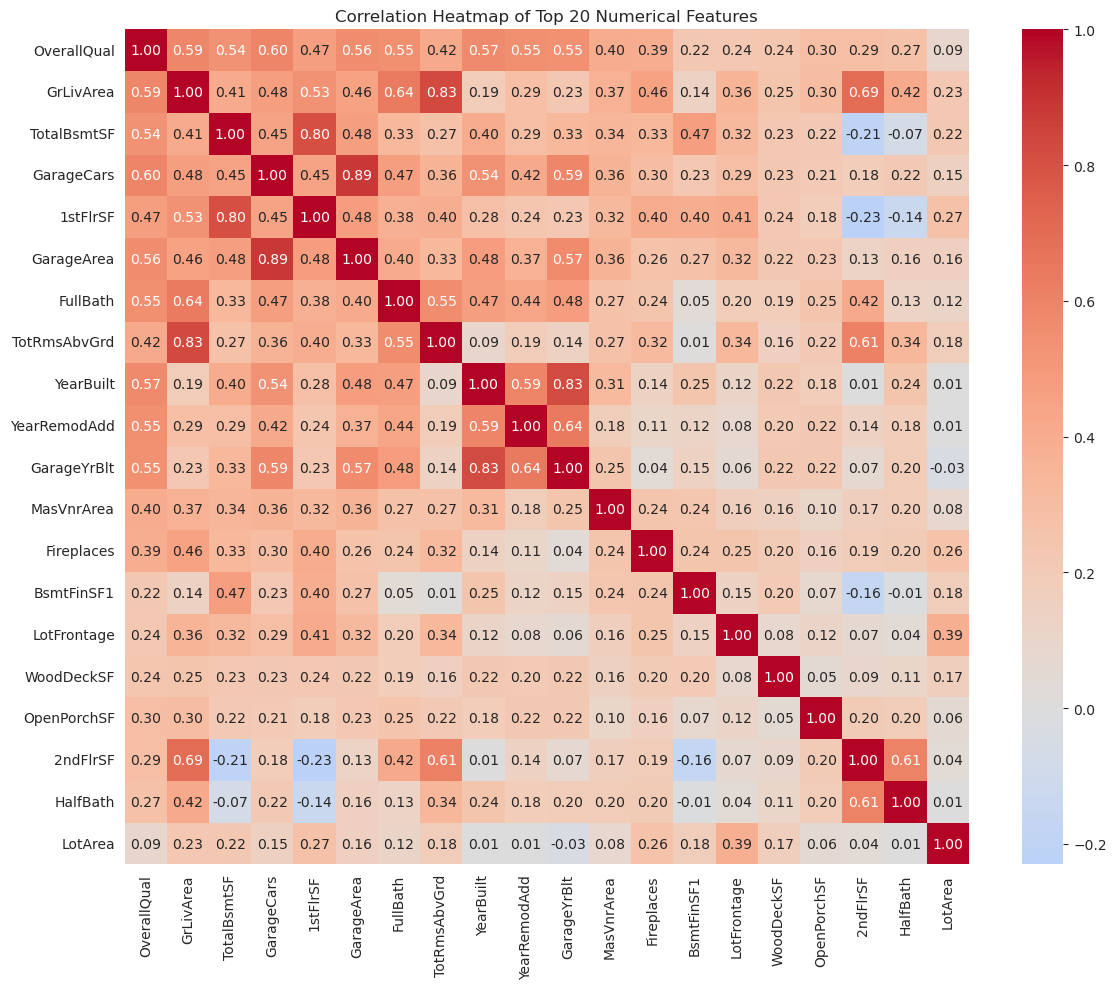

In [16]:
# Compute correlation matrix for numerical features
corr_matrix = X[num_cols].corr()

# Plot heatmap for top correlated features (with SalePrice)
top_corr_features = corr_with_price.head(20).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(X[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Top 20 Numerical Features')
plt.tight_layout()
plt.show()

**Look for:**

- Features that are highly correlated with each other (possible multicollinearity).
- Features that might combine well (e.g., OverallQual and GrLivArea – we already created OverallQual_TotalSF in the baseline transformer).

### 7.2 Pairplot of a few key features

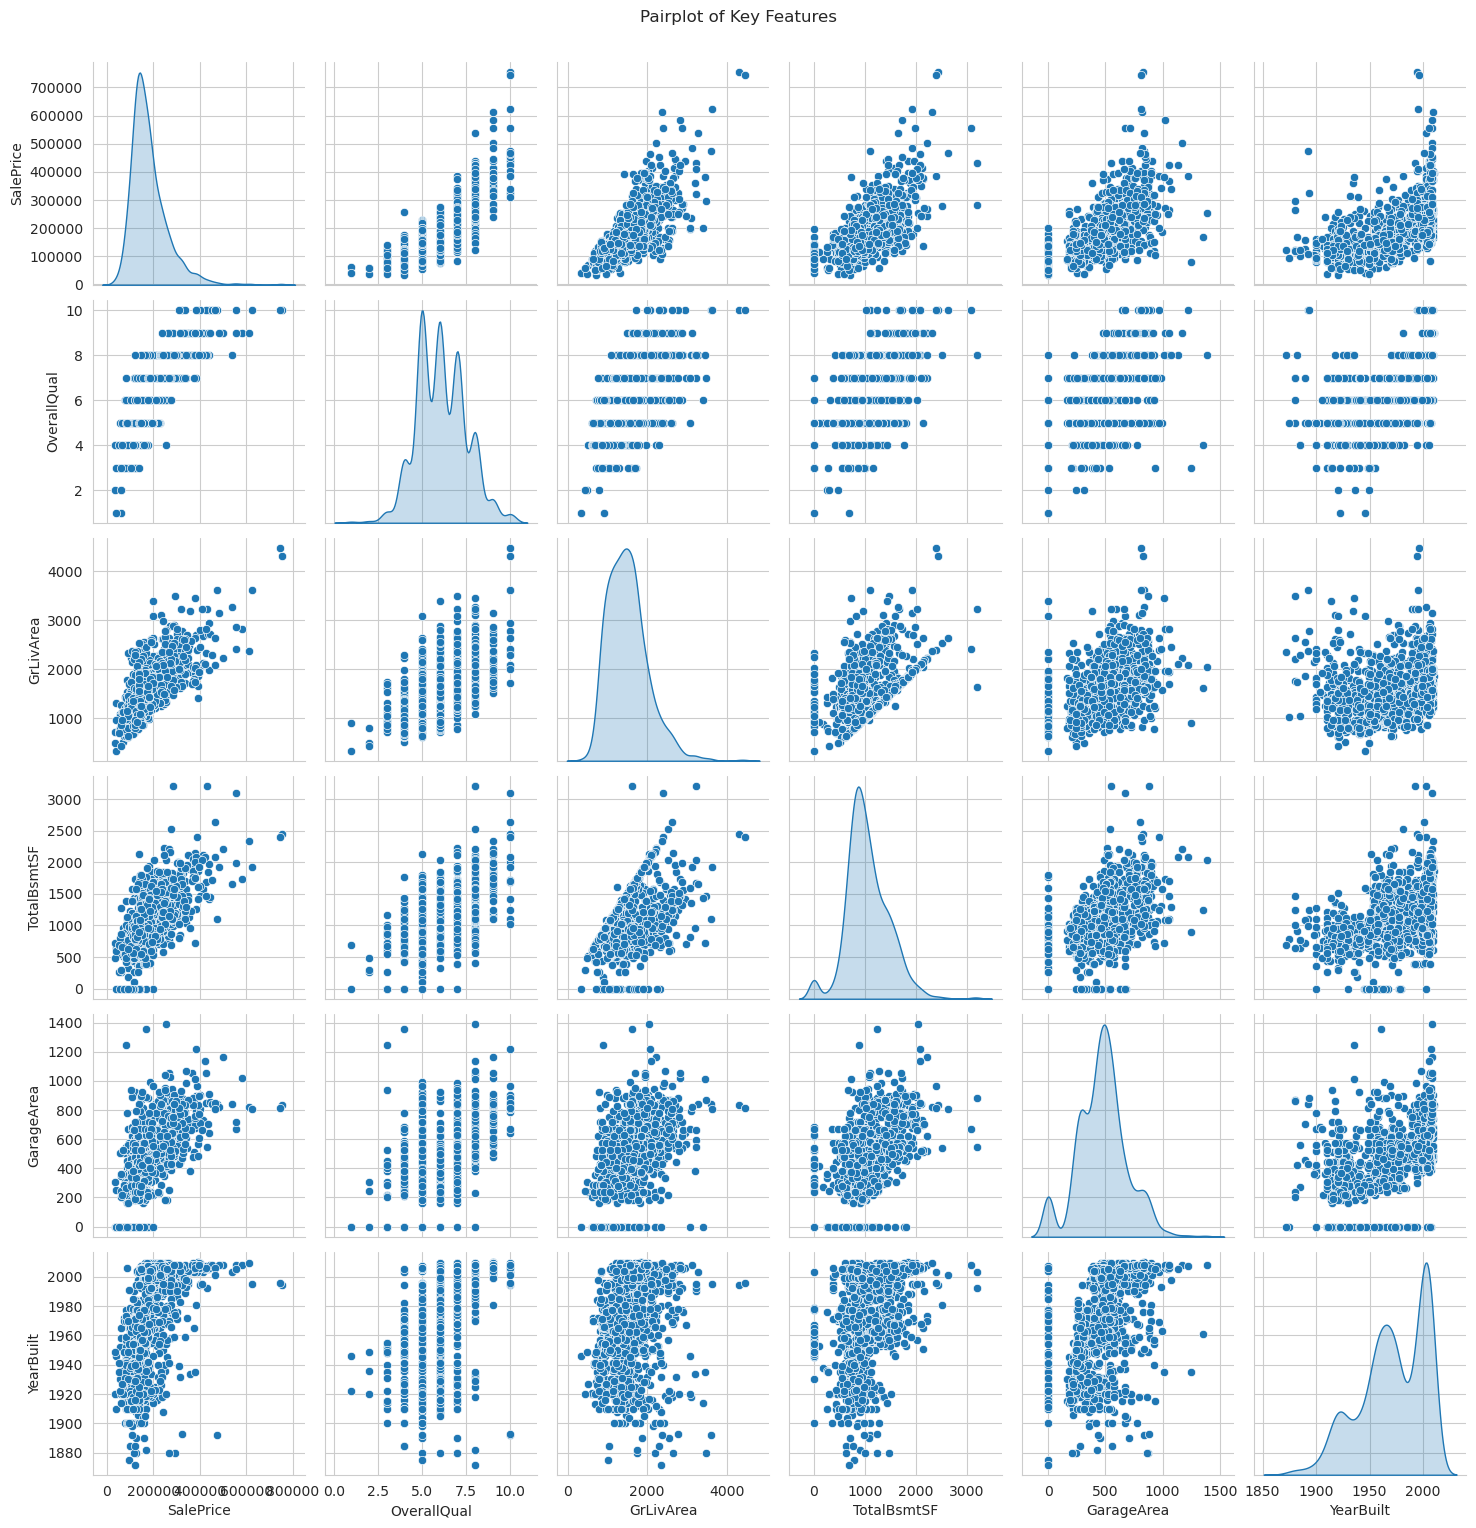

In [17]:
# Select a small subset for pairplot
pair_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']
sns.pairplot(df[pair_cols], diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

## 8. Outlier Re‑examination

Although we removed the two extreme points, there may be other high‑leverage points.

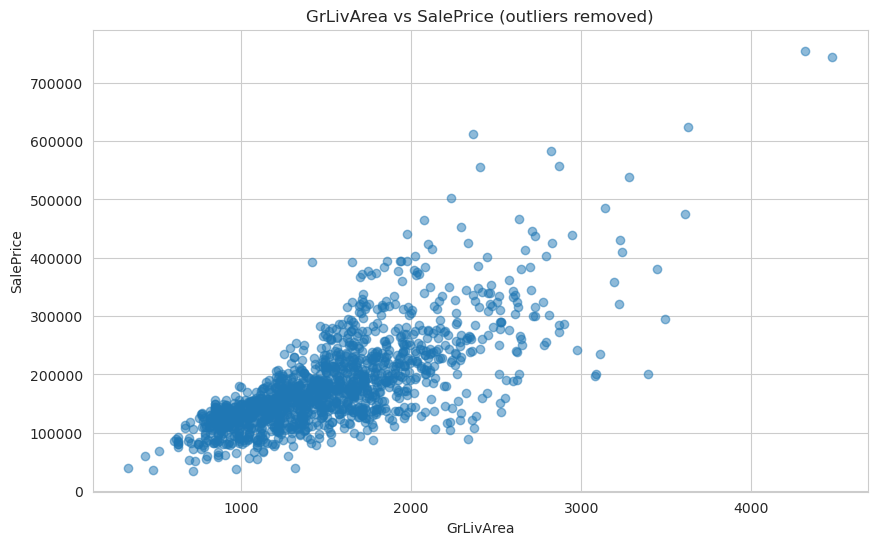

Remaining potential outliers: 0


In [18]:
# Check GrLivArea vs SalePrice again
plt.figure(figsize=(10,6))
plt.scatter(X['GrLivArea'], y, alpha=0.5)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice (outliers removed)')
plt.show()

# Identify any points with high area (>4000) but low price (should be none)
remaining = X[(X['GrLivArea'] > 4000) & (y < 300000)]
print(f"Remaining potential outliers: {len(remaining)}")
if len(remaining) > 0:
    display(df.loc[remaining.index])

**Conclusion:** No more extreme outliers in GrLivArea. However, we may want to investigate other features (e.g., LotArea very large but low price).
## 9. Summary of EDA Findings

-    Target: Highly skewed → log transformation is essential.
-    Missing values: Many categorical missing indicate absence; LotFrontage needs careful imputation (neighborhood median).
-    Key numerical predictors: OverallQual, GrLivArea, TotalBsmtSF, GarageArea, YearBuilt, YearRemodAdd.
-    Categorical predictors: Neighborhood is very important; others like MSZoning, SaleCondition show variation.
-    Potential new features:
 - TotalSF (already in baseline transformer), sum of basement, 1st, 2nd floor.
 - TotalBathrooms (already in transformer).
 - HouseAge and RemodelAge (already in transformer).
 - OverallQual * TotalSF (already in transformer).
 - Neighborhood aggregates: mean price per neighborhood (but careful with leakage).
 - Porch/Deck area: sum of all porch types.
 - Quality × condition interactions.
 - Binned year groups (e.g., decade built).
 - Ratio features: LotArea / TotalSF, GarageArea / TotalSF, etc.
 - Remaining outliers: None obvious, but we'll keep an eye on high‑leverage points during modeling.